In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define the ODE: dy/dx = -2y*cos(x)
def f(x, y):
    return -2 * y * np.cos(x)

# Exact solution: y(x) = exp(-2*sin(x))
def exact_solution(x):
    return np.exp(-2 * np.sin(x))

# Parameters
x_start = 0
x_end = 10 * np.pi
y0 = 1  # Initial condition y(0) = 1

# Step sizes: [0.01, 0.05, 0.15, 0.2, 0.25, ..., 1]
h_values = [0.01, 0.05, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 
            0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0]

# Storage for results
all_x = []
all_y = []
all_errors = []
average_errors = []
errors_at_15 = []

for h in h_values:
    # Calculate number of steps
    num_steps = int((x_end - x_start) / h)
    
    x = []
    y = []
    
    # Initial values
    x.append(x_start)
    y.append(y0)
    
    # Euler's method - simple loop
    for i in range(num_steps):
        x_new = x[i] + h
        y_new = y[i] + h * f(x[i], y[i])
        x.append(x_new)
        y.append(y_new)
    
    # Calculate exact solution at these points
    y_exact = []
    for x_val in x:
        y_exact.append(exact_solution(x_val))
    
    # Calculate local errors
    local_errors = []
    for i in range(len(y)):
        error = abs(y[i] - y_exact[i])
        local_errors.append(error)
    
    # Calculate average error
    sum_errors = 0
    for error in local_errors:
        sum_errors = sum_errors + error
    avg_error = sum_errors / len(local_errors)
    average_errors.append(avg_error)
    
    # Find error at x approximately 15
    best_idx = 0
    best_diff = abs(x[0] - 15)
    for i in range(len(x)):
        diff = abs(x[i] - 15)
        if diff < best_diff:
            best_diff = diff
            best_idx = i
    
    error_at_15 = local_errors[best_idx]
    errors_at_15.append(error_at_15)
    
    all_x.append(x)
    all_y.append(y)
    all_errors.append(local_errors)
    
    print(f"h = {h:.3f}: avg_error = {avg_error:.6f}, error_at_x~15 = {error_at_15:.6f}")


h = 0.010: avg_error = 0.368593, error_at_x~15 = 0.040935
h = 0.050: avg_error = 1.259614, error_at_x~15 = 0.152506
h = 0.150: avg_error = 1.955839, error_at_x~15 = 0.251454
h = 0.200: avg_error = 2.067651, error_at_x~15 = 0.264472
h = 0.250: avg_error = 2.140288, error_at_x~15 = 0.269713
h = 0.300: avg_error = 2.185167, error_at_x~15 = 0.271622
h = 0.350: avg_error = 2.215906, error_at_x~15 = 0.294172
h = 0.400: avg_error = 2.233876, error_at_x~15 = 0.206679
h = 0.450: avg_error = 2.252260, error_at_x~15 = 0.220242
h = 0.500: avg_error = 2.261520, error_at_x~15 = 0.272375
h = 0.550: avg_error = 2.249053, error_at_x~15 = 0.220243
h = 0.600: avg_error = 2.252663, error_at_x~15 = 0.272375
h = 0.650: avg_error = 2.243102, error_at_x~15 = 0.252852
h = 0.700: avg_error = 2.244302, error_at_x~15 = 0.184239
h = 0.750: avg_error = 2.218037, error_at_x~15 = 0.270801
h = 0.800: avg_error = 2.191062, error_at_x~15 = 0.376756
h = 0.850: avg_error = 2.107630, error_at_x~15 = 0.413405
h = 0.900: avg

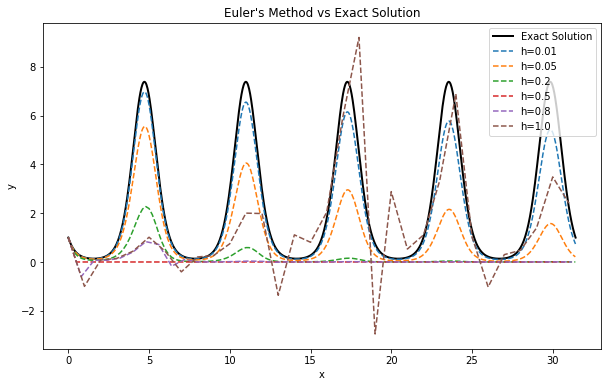

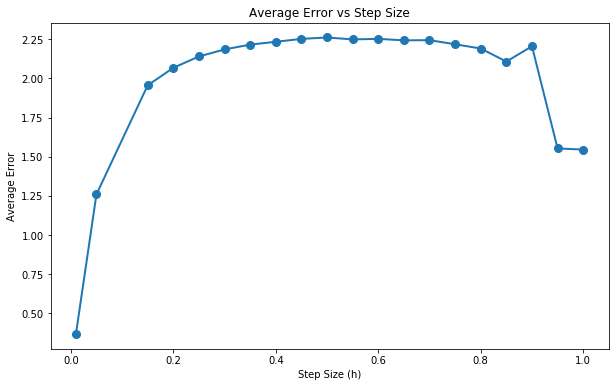

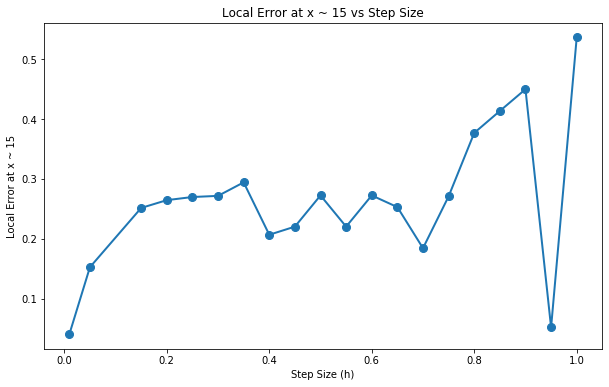

In [2]:
# ============================================================================
# PLOT 1: Euler's method solutions for each value of h
# ============================================================================
plt.figure(figsize=(10, 6))

# Plot exact solution
x_fine = np.linspace(x_start, x_end, 1000)
y_fine = []
for x_val in x_fine:
    y_fine.append(exact_solution(x_val))
plt.plot(x_fine, y_fine, 'k-', linewidth=2, label='Exact Solution')

# Plot some selected h values
selected_indices = [0, 1, 3, 9, 15, 19]  # h = 0.01, 0.05, 0.2, 0.5, 0.8, 1.0
for idx in selected_indices:
    h = h_values[idx]
    plt.plot(all_x[idx], all_y[idx], '--', label=f'h={h}')

plt.xlabel('x')
plt.ylabel('y')
plt.title("Euler's Method vs Exact Solution")
plt.legend()

# ============================================================================
# PLOT 2: Average error vs h
# ============================================================================
plt.figure(figsize=(10, 6))
plt.plot(h_values, average_errors, 'o-', linewidth=2, markersize=8)
plt.xlabel('Step Size (h)')
plt.ylabel('Average Error')
plt.title('Average Error vs Step Size')

# ============================================================================
# PLOT 3: Local error at x approximately 15 vs h
# ============================================================================
plt.figure(figsize=(10, 6))
plt.plot(h_values, errors_at_15, 'o-', linewidth=2, markersize=8)
plt.xlabel('Step Size (h)')
plt.ylabel('Local Error at x ~ 15')
plt.title('Local Error at x ~ 15 vs Step Size')
plt.show()

In [3]:
# Summary
print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)

# Find min/max average error
min_avg_error = average_errors[0]
min_avg_h = h_values[0]
max_avg_error = average_errors[0]
max_avg_h = h_values[0]

for i in range(len(average_errors)):
    if average_errors[i] < min_avg_error:
        min_avg_error = average_errors[i]
        min_avg_h = h_values[i]
    if average_errors[i] > max_avg_error:
        max_avg_error = average_errors[i]
        max_avg_h = h_values[i]

print(f"Smallest average error: h={min_avg_h:.3f}, error={min_avg_error:.6f}")
print(f"Largest average error: h={max_avg_h:.3f}, error={max_avg_error:.6f}")

# Find min/max error at 15
min_error_15 = errors_at_15[0]
min_h_15 = h_values[0]
max_error_15 = errors_at_15[0]
max_h_15 = h_values[0]

for i in range(len(errors_at_15)):
    if errors_at_15[i] < min_error_15:
        min_error_15 = errors_at_15[i]
        min_h_15 = h_values[i]
    if errors_at_15[i] > max_error_15:
        max_error_15 = errors_at_15[i]
        max_h_15 = h_values[i]

print(f"\nSmallest error at x~15: h={min_h_15:.3f}, error={min_error_15:.6f}")
print(f"Largest error at x~15: h={max_h_15:.3f}, error={max_error_15:.6f}")
print("=" * 60)



SUMMARY
Smallest average error: h=0.010, error=0.368593
Largest average error: h=0.500, error=2.261520

Smallest error at x~15: h=0.010, error=0.040935
Largest error at x~15: h=1.000, error=0.536218


In [8]:
print("EXPLANATIONS") #Typed out explanations and refined using Claude
print("=" * 80)
 
print("""
PLOT OBSERVATIONS:
1. Solutions: Small h tracks exact solution well; large h shows drift but stays bounded
2. Avg Error: Increases with h, plateaus around h=0.5, surprisingly drops at h≈1.0
3. Local Error: Erratic depends on where you are in the oscillation cycle
 
The error decrease at h≈1.0 is due to resonance effects. The period of cos(x) is 2π,
so h=1 takes ~6-7 steps per period.
""")
 
print()
print("STABILITY ANALYSIS: dy/dx = -2y·cos(x)")
print("=" * 80)
 
print("""
STEP 1: Identify λ(x)
For dy/dx = λ(x)·y, we have:
    λ(x) = -2·cos(x)
    
This oscillates between:
    λ_min = -2  (when cos(x) = 1)  → Damping region
    λ_max = +2  (when cos(x) = -1) → Growth region
 
STEP 2: Euler's Amplification Factor
Euler's method: y_{n+1} = y_n + h·f(x_n, y_n) = y_n(1 - 2h·cos(x_n))
    
Amplification factor: A(x) = 1 - 2h·cos(x)
 
STEP 3: Stability Conditions
For stability, need |A(x)| ≤ 1 for all x:
 
Case 1 - When cos(x) = 1 (λ = -2):
    |1 - 2h| ≤ 1
    0 ≤ h ≤ 1  ✓ Can be satisfied
 
Case 2 - When cos(x) = -1 (λ = +2):
    |1 + 2h| ≤ 1
    h ≤ 0  ✗ Impossible for positive h!
 
CRITICAL FINDING:
The method is UNCONDITIONALLY UNSTABLE in regions where cos(x) < 0.
However, growth regions are balanced by damping regions, so solutions stay bounded.
""")
 
print("=" * 80)
print("BOUNDING CONDITIONS & THEIR EFFECT ON h")
print("=" * 80)
 
print("""
Amplification at extreme λ values:

When h=0.1, the amplification is modest: ∣A∣=0.8 for the decaying case and ∣A∣=1.2 for the growing case. 
The method performs well here and is considered good. At h=0.5, the decaying case is completely damped out (∣A∣=0.0), 
while the growing case doubles in magnitude (∣A∣=2.0). This is still usable in practice, so it’s labeled practical, 
with amplification limited to about 2×. When h=1.0, the decaying case neither grows nor shrinks (∣A∣=1.0), while the 
growing case triples (∣A∣=3.0). This is considered theoretical—it satisfies stability conditions for decay but introduces 
large growth. At h=1.5, both cases become problematic: the decaying case actually grows (∣A∣=2.0) and the growing case 
increases even more (∣A∣=4.0). The method is unstable at this step size.
 
BOUNDING CONDITIONS:
1. Theoretical bound (from λ = -2): h ≤ 1.0
   - Prevents runaway instability in damping regions
   - Allows 3× amplification in growth regions
 
2. Practical bound (limit |A| ≤ 2): h ≤ 0.5
   - Keeps maximum amplification to 2× everywhere
   - Explains the error plateau at h≈0.5 in plots
   - RECOMMENDED for reliable results
 
3. Accuracy bound: h ≤ 0.1
   - Minimizes truncation error
   - Best for high-precision work
 
Bounding conditions critically affect h choice! Without considering the bounds,
you could select h > 1 and get exponential error growth.
""")
 
print("=" * 80)

EXPLANATIONS

PLOT OBSERVATIONS:
1. Solutions: Small h tracks exact solution well; large h shows drift but stays bounded
2. Avg Error: Increases with h, plateaus around h=0.5, surprisingly drops at h≈1.0
3. Local Error: Erratic depends on where you are in the oscillation cycle
 
The error decrease at h≈1.0 is due to resonance effects. The period of cos(x) is 2π,
so h=1 takes ~6-7 steps per period.


STABILITY ANALYSIS: dy/dx = -2y·cos(x)

STEP 1: Identify λ(x)
For dy/dx = λ(x)·y, we have:
    λ(x) = -2·cos(x)
    
This oscillates between:
    λ_min = -2  (when cos(x) = 1)  → Damping region
    λ_max = +2  (when cos(x) = -1) → Growth region
 
STEP 2: Euler's Amplification Factor
Euler's method: y_{n+1} = y_n + h·f(x_n, y_n) = y_n(1 - 2h·cos(x_n))
    
Amplification factor: A(x) = 1 - 2h·cos(x)
 
STEP 3: Stability Conditions
For stability, need |A(x)| ≤ 1 for all x:
 
Case 1 - When cos(x) = 1 (λ = -2):
    |1 - 2h| ≤ 1
    0 ≤ h ≤ 1  ✓ Can be satisfied
 
Case 2 - When cos(x) = -1 (λ = +2